# Integrative Challenge - Part 1 : Environment (RoboArena 4.0)

The Integrative Challenge is split into three activities. This notebook is only for the first one: building the environment (production line, racks, truck dock, charging stations, parking slot, corridors, pallet positions) on a discrete grid. No AGV agents, no decisions, no communication yet, that's for the next activity.

I used AgentPy, so the grid and the static elements are built as an AgentPy Model, but none of the agents placed here actually do anything (no `step()`), they just hold a position and a type.


In [18]:
!pip install agentpy

# Step 1 - Imports

In [19]:
import agentpy as ap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json

# Step 2 - Layout parameters

Everything about the environment is in one dictionary, `CONFIG`, so I can move something around without touching the rest of the notebook.

1 cell = 0.3 m, roughly the AGV footprint given in the project brief (30x20cm). The real RoboArena 4.0 platform is about 4.5 x 3.5 m, so with this scale I get a 15 x 12 grid (4.5 x 3.6 m, close enough to 3.5).

The production line is the column at x=0 and the truck dock is the column at x=14. Both only have 4 cells you can actually reach: for the production line these are the 4 outputs, for the dock these are 4 doors. I didn't split the dock into separate inbound/outbound zones, a door can be used for either, it depends on the mission and not on the door itself.

The two charging stations are at the two ends of the bottom row and the parking slot (where an AGV waits if both CS are busy) is centered between them.

Corridors are 2 cells wide almost everywhere, except the gap between the two middle racks, which I left at 1 cell on purpose, so I can test later what happens when two AGVs want to go through the same narrow spot at once.


In [20]:
CONFIG = {
    "cell_size_m": 0.3,     # ~ AGV footprint
    "grid_width": 15,       # 15 * 0.3 = 4.5 m
    "grid_height": 12,      # 12 * 0.3 = 3.6 m (real platform is ~3.5 m)

    "production_line": {
        "id": "production_line",
        "x": 0, "y": 0, "w": 1, "h": 12,
        "output_rows": [1, 4, 7, 10],
    },
    "truck_dock": {
        "id": "truck_dock",
        "x": 14, "y": 0, "w": 1, "h": 12,
        "door_rows": [1, 4, 7, 10],
    },

    "racks": [
        {"id": "rack_top",       "x": 5, "y": 10, "w": 5, "h": 2, "pallet_face": "bottom"},
        {"id": "rack_mid_upper", "x": 3, "y": 6,  "w": 4, "h": 2, "pallet_face": "top"},   # top, not bottom, so it doesn't sit right on the narrow gap
        {"id": "rack_mid_lower", "x": 3, "y": 3,  "w": 4, "h": 2, "pallet_face": "bottom"},
        {"id": "rack_vertical",  "x": 9, "y": 3,  "w": 2, "h": 5, "pallet_face": "left"},
    ],
    "max_pallet_slots_per_rack": 4,

    "charging_stations": [
        {"id": "cs_1", "x": 1,  "y": 0, "w": 1, "h": 1},
        {"id": "cs_2", "x": 13, "y": 0, "w": 1, "h": 1},
    ],
    "parking_slot": {"id": "parking_1", "x": 6, "y": 0, "w": 3, "h": 1},
}

# codes for the zone_map array, only used for plotting/debugging
ZONE_CODES = {
    "corridor": 0,
    "rack": 1,
    "charging_station": 2,
    "parking_slot": 3,
    "production_line_wall": 4,
    "production_line_output": 5,
    "truck_dock_wall": 6,
    "truck_dock_door": 7,
    "pallet_position": 8,
}

Each rack can hold up to 4 pallets at the same time. Instead of typing every coordinate by hand, I wrote a small function that spreads the slots along the accessible side of the rack (the side facing a corridor, not a wall or another rack), capped at 4 slots or at the length of that side, whichever is smaller.

In [21]:
def generate_pallet_slots(rack, max_slots):
    x0, y0, w, h = rack["x"], rack["y"], rack["w"], rack["h"]
    face = rack["pallet_face"]

    length = w if face in ("top", "bottom") else h
    nb_slots = min(max_slots, length)
    step = length / nb_slots
    offsets = [int(i * step) for i in range(nb_slots)]

    slots = []
    for off in offsets:
        if face == "bottom":
            slots.append((x0 + off, y0 - 1))
        elif face == "top":
            slots.append((x0 + off, y0 + h))
        elif face == "left":
            slots.append((x0 - 1, y0 + off))
        elif face == "right":
            slots.append((x0 + w, y0 + off))

    return slots


CONFIG["pallet_positions"] = []
for rack in CONFIG["racks"]:
    slots = generate_pallet_slots(rack, CONFIG["max_pallet_slots_per_rack"])
    for i, (x, y) in enumerate(slots):
        CONFIG["pallet_positions"].append({
            "id": rack["id"] + "_pallet_" + str(i + 1),
            "rack_id": rack["id"],
            "x": x, "y": y,
        })

print("total pallet slots:", len(CONFIG["pallet_positions"]))
for rack in CONFIG["racks"]:
    n = len([p for p in CONFIG["pallet_positions"] if p["rack_id"] == rack["id"]])
    print(" -", rack["id"], ":", n, "slots")

total pallet slots: 16
 - rack_top : 4 slots
 - rack_mid_upper : 4 slots
 - rack_mid_lower : 4 slots
 - rack_vertical : 4 slots


# Step 3 - Environment model (AgentPy)

The environment is an AgentPy `Model`. Every cell that belongs to a zone (rack, dock, charging station, ...) gets its own `StaticZoneAgent`, but that agent has no behavior, it only stores a type, an id and whether it's walkable or not.

Next to that I keep a numpy array `walkable` (True/False per cell) and a list `zones` with the x,y,w,h of every element. Those two are what I'll actually reuse in the next activity for the AGV pathfinding and the pickup/drop-off points.


In [22]:
class StaticZoneAgent(ap.Agent):
    # just holds the type of one grid cell, no behavior for this activity

    def setup(self):
        self.zone_type = None
        self.zone_id = None
        self.walkable = False


class LogisticsEnvironment(ap.Model):

    def setup(self):
        p = self.p
        self.width = p["grid_width"]
        self.height = p["grid_height"]

        self.grid = ap.Grid(self, (self.height, self.width), track_empty=True)

        self.zone_map = np.zeros((self.height, self.width), dtype=int)
        self.walkable = np.ones((self.height, self.width), dtype=bool)
        self.zones = []

        self.place_production_line(p["production_line"])
        self.place_truck_dock(p["truck_dock"])

        for rack in p["racks"]:
            self.place_block(rack, "rack", walkable=False)

        for cs in p["charging_stations"]:
            self.place_block(cs, "charging_station", walkable=True)

        self.place_block(p["parking_slot"], "parking_slot", walkable=True)
        self.place_pallet_positions(p["pallet_positions"])

    def add_cell(self, x, y, zone_type, zone_id, walkable):
        agent = StaticZoneAgent(self)
        agent.zone_type = zone_type
        agent.zone_id = zone_id
        agent.walkable = walkable
        self.grid.add_agents([agent], positions=[(y, x)])   # agentpy grid positions are (row, col)
        self.zone_map[y, x] = ZONE_CODES[zone_type]
        self.walkable[y, x] = walkable

    def place_block(self, spec, zone_type, walkable):
        x0, y0, w, h = spec["x"], spec["y"], spec["w"], spec["h"]
        for y in range(y0, y0 + h):
            for x in range(x0, x0 + w):
                self.add_cell(x, y, zone_type, spec["id"], walkable)
        self.zones.append({"id": spec["id"], "type": zone_type, "x": x0, "y": y0, "w": w, "h": h})

    def place_production_line(self, spec):
        x0, y0, w, h = spec["x"], spec["y"], spec["w"], spec["h"]
        outputs = spec["output_rows"]
        for y in range(y0, y0 + h):
            if y in outputs:
                self.add_cell(x0, y, "production_line_output", spec["id"], walkable=True)
            else:
                self.add_cell(x0, y, "production_line_wall", spec["id"], walkable=False)
        self.zones.append({"id": spec["id"], "type": "production_line", "x": x0, "y": y0, "w": w, "h": h})

    def place_truck_dock(self, spec):
        x0, y0, w, h = spec["x"], spec["y"], spec["w"], spec["h"]
        doors = spec["door_rows"]
        for y in range(y0, y0 + h):
            if y in doors:
                self.add_cell(x0, y, "truck_dock_door", spec["id"], walkable=True)
            else:
                self.add_cell(x0, y, "truck_dock_wall", spec["id"], walkable=False)
        self.zones.append({"id": spec["id"], "type": "truck_dock", "x": x0, "y": y0, "w": w, "h": h})

    def place_pallet_positions(self, specs):
        for spec in specs:
            self.add_cell(spec["x"], spec["y"], "pallet_position", spec["id"], walkable=True)
            self.zones.append({"id": spec["id"], "type": "pallet_position",
                                "x": spec["x"], "y": spec["y"], "w": 1, "h": 1,
                                "rack_id": spec["rack_id"]})

In [23]:
env = LogisticsEnvironment(CONFIG)
env.setup()

print("grid size (rows, cols):", env.zone_map.shape)
print("number of zone agents:", len(env.grid.agents))
print("number of zones:", len(env.zones))
print("walkable cells:", env.walkable.sum(), "/", env.walkable.size)

grid size (rows, cols): (12, 15)
number of zone agents: 81
number of zones: 25
walkable cells: 128 / 180


A couple of quick checks on the layout, just printed out instead of a real test suite: that racks/CS/parking don't overlap, that the narrow gap between the two middle racks really is 1 cell wide, and that every pallet slot lands on a walkable cell.

In [24]:
# racks / CS / parking should never overlap each other
occupied = np.zeros_like(env.zone_map)
for z in CONFIG["racks"] + CONFIG["charging_stations"] + [CONFIG["parking_slot"]]:
    occupied[z["y"]:z["y"]+z["h"], z["x"]:z["x"]+z["w"]] += 1
print("max overlap count (should be 1):", occupied.max())

# column x=4 crosses both middle racks and the gap between them
print("walkable column at x=4, from y=0 to y=11:")
print(env.walkable[:, 4].astype(int))

# every pallet slot should be walkable and inside the grid
bad = 0
for p in CONFIG["pallet_positions"]:
    inside = 0 <= p["x"] < env.width and 0 <= p["y"] < env.height
    if not inside or not env.walkable[p["y"], p["x"]]:
        bad += 1
        print("problem with slot:", p)
print(len(CONFIG["pallet_positions"]) - bad, "/", len(CONFIG["pallet_positions"]), "pallet slots OK")

max overlap count (should be 1): 1
walkable column at x=4, from y=0 to y=11:
[1 1 1 0 0 1 0 0 1 1 1 1]
16 / 16 pallet slots OK


# Step 4 - Visualization

To check the layout without reading the code, I draw the grid with matplotlib: a colored rectangle per zone, arrows on the production line outputs and dock doors, and small diamonds for the pallet slots.


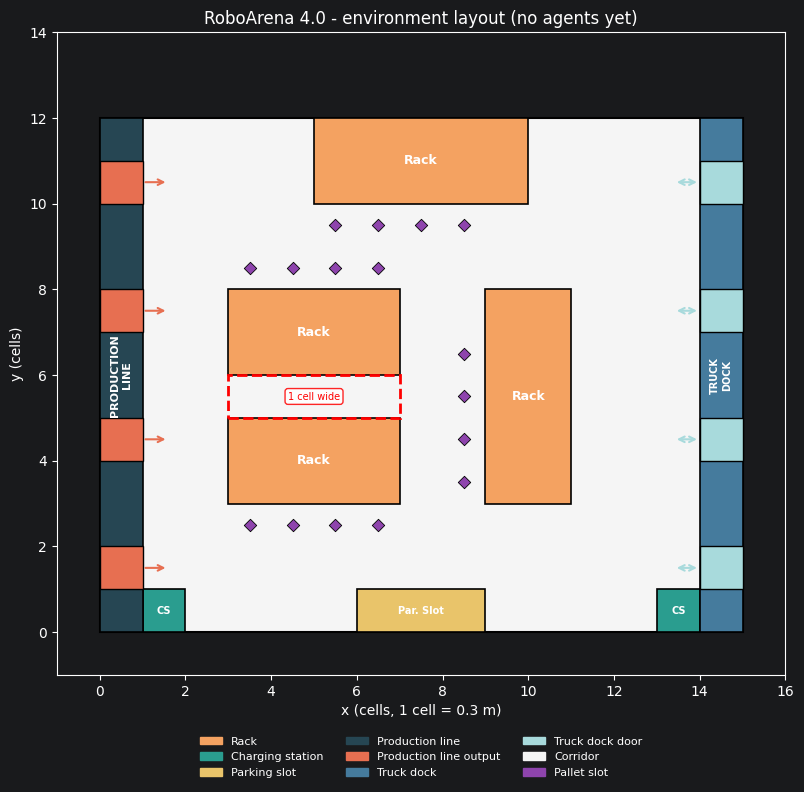

In [25]:
COLORS = {
    "corridor": "#f5f5f5",
    "rack": "#f4a261",
    "charging_station": "#2a9d8f",
    "parking_slot": "#e9c46a",
    "production_line": "#264653",
    "truck_dock": "#457b9d",
    "pallet_position": "#8e44ad",
}


def draw_block(ax, x, y, w, h, color, label, fontsize=9):
    ax.add_patch(mpatches.Rectangle((x, y), w, h, facecolor=color, edgecolor="black", linewidth=1.2, zorder=2))
    ax.text(x + w / 2, y + h / 2, label, ha="center", va="center", color="white", fontsize=fontsize, weight="bold", zorder=3)


def plot_environment(config, save_path=None):
    fig, ax = plt.subplots(figsize=(10, 8))
    W, H = config["grid_width"], config["grid_height"]

    ax.add_patch(mpatches.Rectangle((0, 0), W, H, facecolor=COLORS["corridor"], edgecolor="black", linewidth=1.5))

    for gx in range(W + 1):
        ax.plot([gx, gx], [0, H], color="#dddddd", linewidth=0.5, zorder=0)
    for gy in range(H + 1):
        ax.plot([0, W], [gy, gy], color="#dddddd", linewidth=0.5, zorder=0)

    for r in config["racks"]:
        draw_block(ax, r["x"], r["y"], r["w"], r["h"], COLORS["rack"], "Rack")

    for cs in config["charging_stations"]:
        draw_block(ax, cs["x"], cs["y"], cs["w"], cs["h"], COLORS["charging_station"], "CS", fontsize=7)

    p = config["parking_slot"]
    draw_block(ax, p["x"], p["y"], p["w"], p["h"], COLORS["parking_slot"], "Par. Slot", fontsize=7)

    pl = config["production_line"]
    draw_block(ax, pl["x"], pl["y"], pl["w"], pl["h"], COLORS["production_line"], "")
    for oy in pl["output_rows"]:
        ax.add_patch(mpatches.Rectangle((pl["x"], oy), pl["w"], 1, facecolor="#e76f51", edgecolor="black", zorder=3))
        ax.annotate("", xy=(pl["x"] + pl["w"] + 0.6, oy + 0.5), xytext=(pl["x"] + pl["w"], oy + 0.5),
                    arrowprops=dict(arrowstyle="->", color="#e76f51", lw=1.5), zorder=4)
    ax.text(pl["x"] + pl["w"] / 2, pl["y"] + pl["h"] / 2, "PRODUCTION\nLINE", rotation=90,
            ha="center", va="center", color="white", fontsize=8, weight="bold", zorder=3)

    td = config["truck_dock"]
    draw_block(ax, td["x"], td["y"], td["w"], td["h"], COLORS["truck_dock"], "")
    for dy in td["door_rows"]:
        ax.add_patch(mpatches.Rectangle((td["x"], dy), td["w"], 1, facecolor="#a8dadc", edgecolor="black", zorder=3))
        ax.annotate("", xy=(td["x"] - 0.6, dy + 0.5), xytext=(td["x"], dy + 0.5),
                    arrowprops=dict(arrowstyle="<->", color="#a8dadc", lw=1.5), zorder=4)
    ax.text(td["x"] + td["w"] / 2, td["y"] + td["h"] / 2, "TRUCK\nDOCK", rotation=90,
            ha="center", va="center", color="white", fontsize=7, weight="bold", zorder=3)

    for pp in config["pallet_positions"]:
        ax.scatter(pp["x"] + 0.5, pp["y"] + 0.5, marker="D", s=40,
                   color=COLORS["pallet_position"], edgecolor="black", linewidth=0.6, zorder=5)

    # the narrow passage between the two middle racks, marked so it's easy to spot
    ax.add_patch(mpatches.Rectangle((3, 5), 4, 1, facecolor="none", edgecolor="red", linewidth=2, linestyle="--", zorder=6))
    ax.text(5, 5.5, "1 cell wide", ha="center", va="center", fontsize=7, color="red", zorder=6,
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="red", alpha=0.85))

    ax.set_xlim(-1, W + 1)
    ax.set_ylim(-1, H + 2)
    ax.set_aspect("equal")
    ax.set_xlabel(f"x (cells, 1 cell = {config['cell_size_m']} m)")
    ax.set_ylabel("y (cells)")
    ax.set_title("RoboArena 4.0 - environment layout (no agents yet)")

    legend_items = [
        mpatches.Patch(color=COLORS["rack"], label="Rack"),
        mpatches.Patch(color=COLORS["charging_station"], label="Charging station"),
        mpatches.Patch(color=COLORS["parking_slot"], label="Parking slot"),
        mpatches.Patch(color=COLORS["production_line"], label="Production line"),
        mpatches.Patch(color="#e76f51", label="Production line output"),
        mpatches.Patch(color=COLORS["truck_dock"], label="Truck dock"),
        mpatches.Patch(color="#a8dadc", label="Truck dock door"),
        mpatches.Patch(color=COLORS["corridor"], label="Corridor"),
        mpatches.Patch(color=COLORS["pallet_position"], label="Pallet slot"),
    ]
    ax.legend(handles=legend_items, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=8, frameon=False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


plot_environment(CONFIG, save_path="environment_preview.png")

# Step 5 - Saving the layout

I save the grid size, the list of zones and the walkable mask to a json file. I don't need this for the current activity, but it should save time later for the Unity part since the coordinates will already be there.


In [26]:
export = {
    "grid": {
        "width_cells": CONFIG["grid_width"],
        "height_cells": CONFIG["grid_height"],
        "cell_size_m": CONFIG["cell_size_m"],
    },
    "zones": env.zones,
    "walkable_mask": env.walkable.astype(int).tolist(),
}

with open("layout_export.json", "w") as f:
    json.dump(export, f, indent=2)

print("saved layout_export.json")
print("grid:", CONFIG["grid_width"], "x", CONFIG["grid_height"], "cells")
print("real size:", round(CONFIG["grid_width"] * CONFIG["cell_size_m"], 2), "x",
      round(CONFIG["grid_height"] * CONFIG["cell_size_m"], 2), "m")

saved layout_export.json
grid: 15 x 12 cells
real size: 4.5 x 3.6 m


# Short analysis

**1. How did I represent the environment?**
As a discrete grid, 15 by 12 cells, 0.3 m per cell. It's built as an AgentPy Model, and every cell that belongs to a zone has its own agent (just a type, no behavior). The `walkable` array and the `zones` list are what I actually use for the plot and the export.

**2. What elements did I include?**
Production line (4 outputs), truck dock (4 doors, shared between inbound and outbound), 4 racks, 2 charging stations, 1 parking slot, 16 pallet slots (up to 4 per rack), corridors, and the obstacle cells (the racks themselves, plus the wall parts of the production line and the dock).

**3. What did I change compared to the example seen in class?**
Mostly the scale, I matched it to the real AGV footprint and to the real dimensions of RoboArena 4.0 instead of picking arbitrary numbers. I also merged the production line into one object with 4 outputs instead of 4 separate ones, did the same for the dock instead of two separate inbound/outbound zones, and added the pallet slots and the narrow corridor. I also added a parking slot where AGV can parking waiting for a free charging station.

**4. Why this layout?**
It follows the layout I sketched for RoboArena 4.0: a rack at the top, two stacked racks on the left, one long rack on the right, charging stations and parking at the bottom. Corridors are 2 cells wide almost everywhere so two AGVs can cross, except one gap I left at 1 cell on purpose, to test later what happens when only one AGV can get through.

**5. How did I represent obstacles and walkable areas?**
With a boolean array, `walkable`. It's False on every rack cell and on the wall part of the production line/dock, True everywhere else: corridors, charging stations, parking slot, the 4 outputs, the 4 doors, and the 16 pallet slots.

**6. Where do the 3 flows start and end?**
Flow 1 (production line -> rack or dock) starts at one of the 4 outputs. Flow 2 (rack -> dock) starts at a pallet slot and ends at a door. Flow 3 (dock -> rack) starts at a door and ends at a pallet slot. Since the doors aren't split between inbound and outbound, the direction depends on the mission, not on which door is used.

**7. What matters most for the next activity?**
`walkable` and `zones` mainly, the AGVs will need both to move around and to know where to pick up or drop off a pallet. Also the fact that everything is already inside an AgentPy grid, so I can add the AGV agents directly on top instead of rebuilding the environment.


# Integrative Challenge - Part 2 (M3): AGV Agents and Basic Multi-Agent Interaction

This is the second activity, built on top of the environment notebook from before (same `CONFIG`,
same `env`, nothing about the layout itself changes). Here I add the actual AGV agents: each one
has its own state, they get missions and negotiate over them instead of me assigning things by hand,
and I had to deal with them running into each other and into a couple of extra things I added
(some random obstacles and a pedestrian crossing). Like for M2, no Q-Learning or MDP here, that's
for the next and last activity, this one is just about the agents and how they interact.

I reuse `CONFIG`, `env`, `env.walkable`, `COLORS` and `draw_block` from above instead of rebuilding
the environment.

# Step 6 - Extra imports and pathfinding (BFS)

In [27]:
from collections import deque
import random
import pandas as pd
import matplotlib.animation as animation
from IPython.display import Image, display

random.seed(18)


def bfs_path(walkable, start, goal):
    """Classic BFS shortest path on the grid, 4 directions only, using M2's walkable mask.
    Returns the list of (x, y) cells from start to goal, or None if there's no path."""
    if start == goal:
        return [start]
    H, W = walkable.shape
    visited = {start}
    prev = {}
    q = deque([start])
    while q:
        cx, cy = q.popleft()
        for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
            nx, ny = cx + dx, cy + dy
            if 0 <= nx < W and 0 <= ny < H and walkable[ny, nx] and (nx, ny) not in visited:
                visited.add((nx, ny))
                prev[(nx, ny)] = (cx, cy)
                if (nx, ny) == goal:
                    path = [(nx, ny)]
                    node = (nx, ny)
                    while node != start:
                        node = prev[node]
                        path.append(node)
                    path.reverse()
                    return path
                q.append((nx, ny))
    return None


def bfs_path_avoiding(walkable, start, goal, blocked):
    """Same as bfs_path, but some extra cells are temporarily off-limits (another AGV parked in
    the way, or the pedestrian crossing while it's active). The goal itself is never blocked,
    since by the time the AGV gets there it's probably free again anyway. I use this to route an
    AGV around something instead of just making it wait forever (Step 9)."""
    if start == goal:
        return [start]
    H, W = walkable.shape
    visited = {start}
    prev = {}
    q = deque([start])
    while q:
        cx, cy = q.popleft()
        for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
            nx, ny = cx + dx, cy + dy
            if not (0 <= nx < W and 0 <= ny < H and walkable[ny, nx]):
                continue
            if (nx, ny) in visited:
                continue
            if (nx, ny) in blocked and (nx, ny) != goal:
                continue
            visited.add((nx, ny))
            prev[(nx, ny)] = (cx, cy)
            if (nx, ny) == goal:
                path = [(nx, ny)]
                node = (nx, ny)
                while node != start:
                    node = prev[node]
                    path.append(node)
                path.reverse()
                return path
            q.append((nx, ny))
    return None


def mask_fully_connected(mask, ref):
    """Checks that every walkable cell can still be reached from `ref`. I use this after placing
    the random obstacles (Step 9) to make sure I didn't accidentally wall off part of the
    warehouse."""
    H, W = mask.shape
    if not mask[ref[1], ref[0]]:
        return False
    seen = {ref}
    dq = deque([ref])
    while dq:
        cx, cy = dq.popleft()
        for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
            nx, ny = cx + dx, cy + dy
            if 0 <= nx < W and 0 <= ny < H and mask[ny, nx] and (nx, ny) not in seen:
                seen.add((nx, ny))
                dq.append((nx, ny))
    return len(seen) == int(mask.sum())


W_MASK = env.walkable
print("routing test: (2,0) -> (14,4):", len(bfs_path(W_MASK, (2, 0), (14, 4))) - 1, "cells")

routing test: (2,0) -> (14,4): 16 cells


# Step 7 - A small game-theory model for negotiation and collisions

For the negotiation between AGVs (who gets a mission) and later for collisions (who moves first), I
reused the Cooperate/Defect idea from the Multiagent Interaction slides instead of inventing
something new. Both situations are really the same kind of encounter: two actions, **C**ooperate
(respect whatever the fair process -- negotiation or priority -- would produce) or **D**efect (try
to take the resource anyway), with the payoff matrix below (from my own notes, based on the slides):

| i's action (j's action ->) | C | D |
|---|---|---|
| **C** | (10, 10) | (5, 0) |
| **D** | (0, 5) | (0, 0) |

Unlike the usual Prisoner's Dilemma, I built this one so that C strongly dominates D for both
players: whatever the other one does, cooperating is always at least as good and usually a lot
better. I check that below with the same "strongly dominates" definition from class (`Omega1 >_i
Omega2` iff every outcome of `Omega1` is at least as good as every outcome of `Omega2`, and they're
not identical). So in theory a rational AGV should never Defect. I still let AGVs Defect sometimes
in Step 9 anyway, so this actually gets exercised in the simulation instead of just being true on
paper -- an AGV is more likely to Defect when it's low on battery or already busy, i.e. when being
a bit selfish could actually make sense for it individually, even though the group as a whole is
worse off.

In [28]:
# Payoff matrix: PAYOFF[(action_i, action_j)] = (payoff_i, payoff_j)
PAYOFF = {("C", "C"): (10, 10), ("C", "D"): (5, 0), ("D", "C"): (0, 5), ("D", "D"): (0, 0)}


def strategy_outcomes(role, strategy):
    """All outcomes a player can get by playing `strategy`, across the opponent's two replies."""
    if role == "row":
        return [PAYOFF[(strategy, opp)][0] for opp in ("C", "D")]
    return [PAYOFF[(opp, strategy)][1] for opp in ("C", "D")]


def strongly_dominates(role, s1, s2):
    """s1 strongly dominates s2 for `role` if every outcome from s1 is >= every outcome from s2
    and they're not identical -- same idea as Omega1 >_i Omega2 from the slides."""
    o1, o2 = strategy_outcomes(role, s1), strategy_outcomes(role, s2)
    return min(o1) >= max(o2) and o1 != o2


for role in ("row", "col"):
    print(f"{role} player: outcomes(C)={strategy_outcomes(role,'C')}, outcomes(D)={strategy_outcomes(role,'D')}, "
          f"C dominates D: {strongly_dominates(role, 'C', 'D')}")
print("\nSo Cooperate is the dominant strategy for both agents -- a rational AGV should always")
print("cooperate. The branches below where an AGV defects anyway are there to model that some")
print("AGVs behave a bit selfishly when they're desperate (low battery, etc).")

row player: outcomes(C)=[10, 5], outcomes(D)=[0, 0], C dominates D: True
col player: outcomes(C)=[10, 5], outcomes(D)=[0, 0], C dominates D: True

So Cooperate is the dominant strategy for both agents -- a rational AGV should always
cooperate. The branches below where an AGV defects anyway are there to model that some
AGVs behave a bit selfishly when they're desperate (low battery, etc).


# Step 8 - Pallets and missions

Racks and pallets are not the same thing: the racks (built in the environment notebook) are just
the fixed shelves, `P_j = (ID_j, position_j, status_j)` pallets are the actual objects that move
around. Two of the four slots on each rack start with a pallet already `stored` there, the other two
are left empty and become a mission destination later on. Three more pallets start
`waiting_for_pickup`: two that just came off the production line (Flow 1) and one already sitting
at a dock door from an incoming truck (Flow 3).

A mission is `M_k = (O_k, D_k, P_k, S_k)`: origin, destination, which pallet it's about, and a
status that goes `Pending -> Assigned -> InProgress -> Completed`. I start with 6 missions and
publish 3 more once the simulation is already running (Step 10), so it's not just one fixed batch
handled at the very start.

One thing about the drawing: `generate_pallet_slots` (in the environment notebook) puts every slot
one cell in front of its rack, on the accessible side, because rack cells are `walkable=False` and
an AGV can't stand inside a rack. Routing always uses that real coordinate. Only for the animation I
shift the pallet marker back onto the rack (`visual_pallet_position`, Step 9), so it actually looks
like it's sitting on the shelf instead of floating in the aisle in front of it.

In [29]:
class Pallet:
    def __init__(self, pid, position, status):
        self.id, self.position, self.status = pid, position, status
    def __repr__(self):
        return f"Pallet({self.id},{self.position},{self.status})"


class Mission:
    def __init__(self, mid, origin, destination, pallet_id, flow):
        self.id, self.origin, self.destination = mid, origin, destination
        self.pallet_id, self.flow = pallet_id, flow
        self.status = "Pending"   # Pending -> Assigned -> InProgress -> Completed
        self.agv = None
    def __repr__(self):
        return f"Mission({self.id},{self.flow},{self.origin}->{self.destination},{self.status})"


print("Mission and Pallet classes ready. Pallets/missions themselves are built inside the model below,")
print("so they start fresh every time the simulation is (re)run.")

Mission and Pallet classes ready. Pallets/missions themselves are built inside the model below,
so they start fresh every time the simulation is (re)run.


# Step 9 - AGV agent and the multi-agent system model

`AGVAgent` is a real `ap.Agent`, each one keeps its own `s_i = (position_i, battery_i, status_i,
mission_i)` plus a `label` (`AGV-1` to `AGV-5`) so I can always tell them apart in the log and the
animation -- they're 5 separate agents, not one point copied 5 times.

`MultiAGVSystem` is the `ap.Model` that owns the fleet, the pallets and the missions. It acts as the
Mission Manager: it publishes missions and keeps track of what's assigned or completed, but it never
decides by itself which AGV does which mission -- that comes out of `_negotiate()` below.

### Communication and negotiation

When a mission is published, every `Available` AGV with enough battery gets
`Message_k = (MissionID, Origin, Destination, Pallet)` (I print a concrete example in Step 10) and
computes a bid `U_i,k = -w_d D_i,k + w_b B_i - w_l L_i` (`D` = BFS distance to the mission's origin,
`B` = battery, `L` = missions already completed, as a small fairness penalty so the same AGV doesn't
hog everything), using the weights given in the assignment: `w_d=2, w_b=0.5, w_l=20`.

On top of that I added the Cooperate/Defect layer from Step 7: each eligible AGV also decides
**C** (respect the bidding result) or **D** (try to grab the mission anyway), with a probability of
D that grows as its battery gets close to the bidding cutoff. Three things can happen: if everyone
Cooperates, the highest bidder wins, same as a normal auction. If exactly one AGV Defects, it just
takes the mission, skipping the bidding entirely (I log this as an irregular event so it's easy to
find). If two or more Defect, nobody gets the mission this round, it stays `Pending` and gets
retried on the next step -- that's the "if 2D, reconsider bidding" from my notes.

### Collisions and moving around

Before any AGV actually moves, `_resolve_and_move()` figures out where everyone wants to go next and
sorts out three kinds of conflict, using the same C/D idea and a priority score built from proximity
to the goal, battery, and whether the AGV is already on a mission (`Transporting > ToPickup >
ToCharge`). Two AGVs planning the same next cell, or swapping cells, get resolved by priority: the
higher one goes, the other yields -- and sometimes the loser Defects too (more likely if it's
`Transporting` a pallet or low on battery), in which case both just stay put instead of actually
colliding. If an AGV's next cell is occupied by a stationary AGV, it reroutes around it with
`bfs_path_avoiding` instead of waiting forever, unless there really is no way around. I also ran
into a case where an idle AGV parked exactly on another AGV's path would block it indefinitely,
since an idle AGV has no reason of its own to move -- I added `_nudge_idle_blockers` so it steps
aside instead of just sitting there.

### Obstacles and the pedestrian crossing

I added a few random obstacles and a pedestrian crossing on top of that, since the brief mentions
both AGVs avoiding obstacles and dealing with people walking through the zone. The obstacles
(`N_OBSTACLES = 6` cells) are drawn once at `setup()`, never on a start position, a charging
station, the parking slot, a dock or a pallet slot, and I check with `mask_fully_connected` (Step 6)
that removing them doesn't cut the warehouse into two unreachable halves -- if it does, I just
redraw. Once they're placed they get merged straight into `self.walkable`, so every routing call
just avoids them exactly like it avoids a rack cell, no extra "obstacle" code path needed.

The pedestrian crossing is different: a fixed 3-cell strip across the main aisle (`PEDESTRIAN_CELLS`)
that's active (blocked) for `PEDESTRIAN_ACTIVE_DURATION = 3` steps out of every `PEDESTRIAN_PERIOD =
8`, on a schedule, instead of an actual person walking around. I decided this one shouldn't go
through the Cooperate/Defect game at all -- a pedestrian isn't an agent negotiating for anything,
it's a safety rule -- so `_enforce_pedestrian_safety()` runs first and just refuses to let any AGV
step there while it's active, no matter its priority or how urgent its mission is. If a detour
exists the AGV takes it (`bfs_path_avoiding`), otherwise it just waits until the crossing clears.

### Battery

Battery goes down by `c_d = 1.5` per cell moved. Below `B_threshold = 30` the AGV stops bidding and
heads to the nearest charging station once it's free; while charging it gains `r_c = 10` per step
until it's back above `B_charged = 80`, then it becomes `Available` again.

In [30]:
class AGVAgent(ap.Agent):
    def setup(self):
        self.label = None
        self.pos = None
        self.battery = 100.0
        self.status = "Available"     # Available | ToPickup | Transporting | ToCharge | Charging
        self.mission = None
        self.carried_pallet = None
        self.path = []
        self.missions_completed = 0
        self.distance_traveled = 0


class MultiAGVSystem(ap.Model):

    N_AGV = 5
    START_POSITIONS = [(2, 0), (5, 0), (7, 0), (10, 0), (12, 0)]
    B_MAX, B_THRESHOLD, B_CHARGED = 100.0, 30.0, 80.0
    C_D, R_C = 1.5, 10.0                      # battery cost per cell / gain per charging step
    W_D, W_B, W_L = 2.0, 0.5, 20.0            # negotiation utility weights
    N_STEPS = 60
    DYNAMIC_MISSIONS_AT = (15, 30, 45)        # steps at which a new mission is published mid-run

    N_OBSTACLES = 6                                          # static obstacles, drawn once
    PEDESTRIAN_CELLS = frozenset({(9, 0), (9, 1), (9, 2)})    # fixed crosswalk cells
    PEDESTRIAN_PERIOD = 8                                     # crossing cycles every 8 steps
    PEDESTRIAN_ACTIVE_DURATION = 3                            # ...active (blocked) for 3 of them

    def setup(self):
        self.charging_stations = [(cs["x"], cs["y"]) for cs in CONFIG["charging_stations"]]
        self.log = []
        self.history = []
        self.missions = {}
        self._mission_counter = 0
        self.pallets = {}
        self.stats = {"mission_defect_seize": 0, "mission_mutual_defect": 0,
                       "collision_yield": 0, "collision_mutual_defect": 0,
                       "pedestrian_wait": 0, "pedestrian_reroute": 0}
        self._build_pallets_and_missions()

        self.obstacles = self._generate_obstacles(self.N_OBSTACLES)
        self.walkable = W_MASK.copy()
        for (ox, oy) in self.obstacles:
            self.walkable[oy, ox] = False
        assert mask_fully_connected(self.walkable, self.START_POSITIONS[0]), \
            "obstacle placement broke grid connectivity"

        self.agvs = ap.AgentList(self, self.N_AGV, AGVAgent)
        for i, (a, pos) in enumerate(zip(self.agvs, self.START_POSITIONS), start=1):
            a.label = f"AGV-{i}"
            a.pos = pos

        self._publish(list(self.missions.keys()))

    # ---------------------------------------------------------------
    # Static obstacles and the pedestrian crossing (Step 9 markdown)
    # ---------------------------------------------------------------
    def _generate_obstacles(self, n, max_attempts=300):
        reserved = set(self.START_POSITIONS) | set(self.charging_stations)
        reserved |= {(p["x"], p["y"]) for p in CONFIG["pallet_positions"]}
        ps = CONFIG["parking_slot"]
        reserved |= {(ps["x"] + i, ps["y"]) for i in range(ps["w"])}
        for row in CONFIG["production_line"]["output_rows"]:
            reserved.add((0, row))
        for row in CONFIG["truck_dock"]["door_rows"]:
            reserved.add((14, row))
        reserved |= set(self.PEDESTRIAN_CELLS)

        H, W = W_MASK.shape
        candidates = [(x, y) for y in range(H) for x in range(W)
                      if W_MASK[y, x] and (x, y) not in reserved]

        ref = self.START_POSITIONS[0]
        for _ in range(max_attempts):
            if len(candidates) < n:
                break
            chosen = set(random.sample(candidates, n))
            trial = W_MASK.copy()
            for (x, y) in chosen:
                trial[y, x] = False
            if mask_fully_connected(trial, ref):
                return chosen
        return set()  # extremely unlikely fallback: run with no obstacles rather than risk a broken grid

    def _pedestrian_active(self, t=None):
        t = self.t if t is None else t
        return (t % self.PEDESTRIAN_PERIOD) < self.PEDESTRIAN_ACTIVE_DURATION

    def _active_pedestrian_cells(self, t=None):
        return set(self.PEDESTRIAN_CELLS) if self._pedestrian_active(t) else set()

    def _plan_path(self, start, goal):
        """Used whenever an AGV picks a fresh destination (new mission leg, heading to charge...).
        Avoids the pedestrian crossing if it's active right now and a detour exists; the check in
        _resolve_and_move() still re-verifies this every step, since the crossing can turn on
        again while the AGV is already on its way."""
        avoid = self._active_pedestrian_cells()
        path = bfs_path_avoiding(self.walkable, start, goal, avoid) if avoid else None
        if path is None:
            path = bfs_path(self.walkable, start, goal)
        return path

    def _log(self, msg):
        self.log.append(f"[t={self.t:02d}] {msg}")

    def _use_empty_slot(self):
        return self._empty_slots.pop(0)

    def _new_mission(self, origin, destination, pallet_id, flow):
        self._mission_counter += 1
        mid = f"M{self._mission_counter:02d}"
        self.missions[mid] = Mission(mid, origin, destination, pallet_id, flow)
        return mid

    def _build_pallets_and_missions(self):
        pos_by_slot = {p["id"]: (p["x"], p["y"]) for p in CONFIG["pallet_positions"]}
        self._pos_by_slot = pos_by_slot
        self._empty_slots = []

        # visual-only offset so a pallet renders ON its rack instead of in the aisle in front of it
        self.slot_visual_offset = {}
        for rack in CONFIG["racks"]:
            dx, dy = {"bottom": (0, 1), "top": (0, -1), "left": (1, 0), "right": (-1, 0)}[rack["pallet_face"]]
            for pp in CONFIG["pallet_positions"]:
                if pp["rack_id"] == rack["id"]:
                    self.slot_visual_offset[(pp["x"], pp["y"])] = (dx, dy)

        for rack in CONFIG["racks"]:
            for n in (1, 2):
                slot_id = f"{rack['id']}_pallet_{n}"
                self.pallets[f"P_{slot_id}"] = Pallet(f"P_{slot_id}", pos_by_slot[slot_id], "stored")
            for n in (3, 4):
                slot_id = f"{rack['id']}_pallet_{n}"
                self._empty_slots.append((slot_id, pos_by_slot[slot_id]))

        self.pallets["P_prod_1"] = Pallet("P_prod_1", (0, 1), "waiting_for_pickup")
        self.pallets["P_prod_2"] = Pallet("P_prod_2", (0, 10), "waiting_for_pickup")
        self.pallets["P_in_1"] = Pallet("P_in_1", (14, 7), "waiting_for_pickup")

        self._new_mission(pos_by_slot["rack_top_pallet_1"], (14, 1), "P_rack_top_pallet_1", "Flow2")
        self._new_mission(pos_by_slot["rack_mid_upper_pallet_1"], (14, 4), "P_rack_mid_upper_pallet_1", "Flow2")
        _, dest = self._use_empty_slot()
        self._new_mission((0, 1), dest, "P_prod_1", "Flow1")
        _, dest = self._use_empty_slot()
        self._new_mission((14, 7), dest, "P_in_1", "Flow3")
        self._new_mission(pos_by_slot["rack_mid_lower_pallet_1"], (14, 10), "P_rack_mid_lower_pallet_1", "Flow2")
        _, dest = self._use_empty_slot()
        self._new_mission((0, 10), dest, "P_prod_2", "Flow1")

    def visual_pallet_position(self, pos):
        dx, dy = self.slot_visual_offset.get(pos, (0, 0))
        return (pos[0] + dx, pos[1] + dy)

    def _publish(self, mids):
        for mid in mids:
            self._log(f"Mission {mid} published")

    def _dynamic_mission(self, step):
        if step == 15:
            self.pallets["P_prod_3"] = Pallet("P_prod_3", (0, 4), "waiting_for_pickup")
            _, dest = self._use_empty_slot()
            mid = self._new_mission((0, 4), dest, "P_prod_3", "Flow1")
        elif step == 30:
            dest = self._pos_by_slot["rack_top_pallet_2"]
            mid = self._new_mission(dest, (14, 1), "P_rack_top_pallet_2", "Flow2")
        elif step == 45:
            self.pallets["P_in_2"] = Pallet("P_in_2", (14, 10), "waiting_for_pickup")
            _, dest = self._use_empty_slot()
            mid = self._new_mission((14, 10), dest, "P_in_2", "Flow3")
        self._publish([mid])

    def _nearest_charging_station(self, pos):
        return min(self.charging_stations, key=lambda cs: abs(cs[0] - pos[0]) + abs(cs[1] - pos[1]))

    def _utility(self, agv, mission):
        dist = len(self._plan_path(agv.pos, mission.origin)) - 1
        return -self.W_D * dist + self.W_B * agv.battery - self.W_L * agv.missions_completed, dist

    def _mission_defect_probability(self, agent):
        # small baseline chance of defecting, growing as the AGV's battery gets close to the
        # bidding cutoff (it might not get another good chance for a while).
        margin = agent.battery - self.B_THRESHOLD
        urgency = max(0.0, (40.0 - margin) / 60.0)
        return min(0.5, 0.12 + urgency)

    def _negotiate(self):
        for mid, m in list(self.missions.items()):
            if m.status != "Pending":
                continue

            eligible = []
            for a in self.agvs:
                if a.status != "Available":
                    self._log(f"  {a.label} unavailable (status={a.status})")
                    continue
                if a.battery <= self.B_THRESHOLD:
                    self._log(f"  {a.label} unavailable (battery {a.battery:.1f}% <= threshold)")
                    continue
                eligible.append(a)
            if not eligible:
                continue

            # each eligible AGV rolls Cooperate (respect the bidding result) or Defect (try to
            # grab the mission regardless) independently, same idea as the Step 7 payoff matrix.
            actions = {a: ("D" if random.random() < self._mission_defect_probability(a) else "C")
                       for a in eligible}
            defectors = [a for a in eligible if actions[a] == "D"]

            if len(defectors) >= 2:
                names = ", ".join(a.label for a in defectors)
                self._log(f"  {mid}: mutual defection ({names}) -> reconsidering next step (payoff D,D=0,0)")
                self.stats["mission_mutual_defect"] += 1
                continue  # no assignment this round; every Pending mission is retried next step

            if len(defectors) == 1:
                winner = defectors[0]
                self.stats["mission_defect_seize"] += 1
                self._log(f"  {mid}: {winner.label} DEFECTS and seizes the mission out of turn "
                          f"(payoff if it had cooperated instead: {PAYOFF['C','C'][0]})")
            else:
                bids = []
                for a in eligible:
                    u, dist = self._utility(a, m)
                    bids.append((u, a))
                    self._log(f"  {a.label} bid: {u:.1f} (dist={dist}, battery={a.battery:.1f}%)")
                bids.sort(key=lambda b: b[0], reverse=True)
                winner = bids[0][1]
                self._log(f"  {mid}: all agents cooperate (C strongly dominates D) "
                          f"-> negotiation winner is {winner.label}")

            m.status, m.agv = "Assigned", winner.label
            winner.mission, winner.status = m.id, "ToPickup"
            winner.path = self._plan_path(winner.pos, m.origin)[1:]
            self.pallets[m.pallet_id].status = "reserved"
            self._log(f"{winner.label} accepts Mission {m.id}")

    # ---------------------------------------------------------------
    # Movement with collision resolution
    # ---------------------------------------------------------------
    def _agv_goal(self, a):
        if a.status == "ToPickup":
            return self.missions[a.mission].origin
        if a.status == "Transporting":
            return self.missions[a.mission].destination
        if a.status == "ToCharge":
            return self._nearest_charging_station(a.pos)
        return None

    def _priority(self, a):
        proximity = 1.0 / (1 + len(a.path))
        battery = a.battery / 100.0
        stake = {"Transporting": 1.0, "ToPickup": 0.5, "ToCharge": 0.2}.get(a.status, 0.0)
        return 0.4 * proximity + 0.3 * battery + 0.3 * stake

    def _collision_defect_probability(self, a):
        p = 0.12
        if a.status == "Transporting":
            p += 0.2
        if a.battery < 50:
            p += 0.2
        return min(0.5, p)

    def _resolve_conflict(self, agents_here, blocked, cell):
        scored = sorted(agents_here, key=lambda a: self._priority(a), reverse=True)
        winner = scored[0]
        for loser in scored[1:]:
            if random.random() < self._collision_defect_probability(loser):
                self._log(f"  COLLISION at {cell}: {loser.label} defects against {winner.label} "
                          f"-> both yield this step (mutual defection avoided)")
                self.stats["collision_mutual_defect"] += 1
                blocked.add(winner)
                blocked.add(loser)
                return
        for loser in scored[1:]:
            blocked.add(loser)
            self.stats["collision_yield"] += 1
            self._log(f"  COLLISION avoided at {cell}: {loser.label} yields to {winner.label} "
                      f"(priority {self._priority(winner):.2f} vs {self._priority(loser):.2f})")

    def _nudge_idle_blockers(self, movers):
        """An idle (Available) AGV sitting on a cell another AGV's route actually needs would
        otherwise block it forever, since an idle AGV has no reason of its own to move. So I make
        it step aside -- preferring a cell that isn't itself on someone else's route (and never
        an active pedestrian cell), so it doesn't just become the new bottleneck."""
        reserved = set()
        for a in movers:
            reserved.update(a.path)
        occupied = {a.pos: a for a in self.agvs}
        active_ped = self._active_pedestrian_cells()
        H, W = self.walkable.shape
        for a in self.agvs:
            if a.status != "Available" or a.pos not in reserved:
                continue
            candidates = []
            for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                nx, ny = a.pos[0] + dx, a.pos[1] + dy
                if (0 <= nx < W and 0 <= ny < H and self.walkable[ny, nx]
                        and (nx, ny) not in occupied and (nx, ny) not in active_ped):
                    candidates.append((nx, ny))
            if not candidates:
                continue
            free = [c for c in candidates if c not in reserved]
            dest = free[0] if free else candidates[0]
            self._log(f"  {a.label} (idle) steps aside from {a.pos} to {dest}, freeing the way for another AGV")
            occupied.pop(a.pos, None)
            a.pos = dest
            occupied[a.pos] = a

    def _enforce_pedestrian_safety(self, movers, planned, blocked):
        """Hard rule, no C/D negotiation here: an AGV can never step onto an active pedestrian
        crossing, whatever its priority, mission urgency or battery. If the crossing is active it
        tries to reroute around it; if there's no way around, it just waits -- the crossing is
        only active for a few steps at a time anyway."""
        active_ped = self._active_pedestrian_cells()
        if not active_ped:
            return
        occupied_now = {o.pos for o in self.agvs}
        for a in movers:
            if a in blocked or planned[a] not in active_ped:
                continue
            goal = self._agv_goal(a)
            avoid = occupied_now | active_ped
            new_path = bfs_path_avoiding(self.walkable, a.pos, goal, avoid) if goal else None
            if new_path and len(new_path) > 1 and new_path[1] not in active_ped:
                blocked_cell = a.path[0] if a.path else None
                a.path = new_path[1:]
                planned[a] = a.path[0]
                self.stats["pedestrian_reroute"] += 1
                self._log(f"  PEDESTRIAN CROSSING active at {blocked_cell}: "
                          f"{a.label} reroutes to avoid it (absolute safety rule, no negotiation)")
                continue
            blocked.add(a)
            self.stats["pedestrian_wait"] += 1
            self._log(f"  PEDESTRIAN CROSSING active: {a.label} waits at {a.pos} rather than enter "
                       f"{sorted(active_ped)} (absolute safety rule, no negotiation)")

    def _resolve_and_move(self):
        movers = [a for a in self.agvs if a.status in ("ToPickup", "Transporting", "ToCharge") and a.path]
        self._nudge_idle_blockers(movers)
        planned = {a: a.path[0] for a in movers}

        blocked = set()

        # Pedestrian safety is an absolute constraint, checked before any AGV-AGV priority
        # contest -- a pedestrian crossing is never something an AGV can "win" against.
        self._enforce_pedestrian_safety(movers, planned, blocked)

        by_cell = {}
        for a, cell in planned.items():
            if a in blocked:
                continue
            by_cell.setdefault(cell, []).append(a)

        for cell, agents_here in by_cell.items():
            if len(agents_here) > 1:
                self._resolve_conflict(agents_here, blocked, cell)

        checked = set()
        for a in movers:
            for b in movers:
                if a is b or (a, b) in checked or (b, a) in checked:
                    continue
                checked.add((a, b))
                if a in blocked or b in blocked:
                    continue
                if planned[a] == b.pos and planned[b] == a.pos:
                    self._resolve_conflict([a, b], blocked, "swap")

        # A mover whose next cell is occupied by an AGV that isn't moving out of the way this
        # step (Available / Charging / already-blocked) reroutes around it -- still simple BFS,
        # just re-run with that cell (and any active pedestrian cells) excluded -- instead of
        # queuing behind it indefinitely.
        active_ped = self._active_pedestrian_cells()
        for a in movers:
            if a in blocked:
                continue
            target = planned[a]
            occupant = next((o for o in self.agvs if o is not a and o.pos == target), None)
            if occupant is None:
                continue
            goal = self._agv_goal(a)
            occupied_now = {o.pos for o in self.agvs if o is not a} | active_ped
            new_path = bfs_path_avoiding(self.walkable, a.pos, goal, occupied_now) if goal else None
            if new_path and len(new_path) > 1:
                a.path = new_path[1:]
                planned[a] = a.path[0]
                self.stats["collision_yield"] += 1
                self._log(f"  COLLISION avoided at {target}: {a.label} reroutes around stationary {occupant.label}")
                if planned[a] != target:
                    continue
            blocked.add(a)
            self.stats["collision_yield"] += 1
            self._log(f"  COLLISION avoided at {target}: {a.label} waits (no alternate route), {occupant.label} in the way")

        # safety net: rerouting above could in principle introduce a fresh clash between two
        # movers -- re-check and block all but the highest-priority agent in any such group.
        by_cell2 = {}
        for a in movers:
            if a in blocked:
                continue
            by_cell2.setdefault(planned[a], []).append(a)
        for cell, agents_here in by_cell2.items():
            if len(agents_here) > 1:
                scored = sorted(agents_here, key=lambda a: self._priority(a), reverse=True)
                for loser in scored[1:]:
                    blocked.add(loser)
                    self.stats["collision_yield"] += 1
                    self._log(f"  COLLISION avoided at {cell}: {loser.label} yields to {scored[0].label} (post-reroute safety check)")

        for a in self.agvs:
            if a in blocked:
                continue
            self._update_agv(a)

    def _update_agv(self, a):
        if a.status in ("ToPickup", "Transporting", "ToCharge") and a.path:
            a.pos = a.path.pop(0)
            a.distance_traveled += 1
            if a.status != "ToCharge":
                a.battery = max(0.0, a.battery - self.C_D)

        if a.status == "ToPickup" and not a.path:
            m = self.missions[a.mission]
            pallet = self.pallets[m.pallet_id]
            pallet.status = "being_transported"
            a.carried_pallet = pallet.id
            a.status = "Transporting"
            m.status = "InProgress"
            a.path = self._plan_path(a.pos, m.destination)[1:]
            self._log(f"{a.label} reached pallet {pallet.id}")
            self._log(f"{a.label} transporting {pallet.id}")

        elif a.status == "Transporting" and not a.path:
            m = self.missions[a.mission]
            pallet = self.pallets[m.pallet_id]
            pallet.position = a.pos
            pallet.status = "delivered" if m.flow == "Flow2" else "stored"
            a.carried_pallet = None
            m.status = "Completed"
            a.missions_completed += 1
            self._log(f"{a.label} completed Mission {m.id}")
            a.mission = None
            if a.battery <= self.B_THRESHOLD:
                a.status = "ToCharge"
                a.path = self._plan_path(a.pos, self._nearest_charging_station(a.pos))[1:]
                self._log(f"{a.label} battery low ({a.battery:.1f}%), heading to charge")
            else:
                a.status = "Available"

        elif a.status == "ToCharge" and not a.path:
            a.status = "Charging"
            self._log(f"{a.label} charging at {a.pos}")

        elif a.status == "Charging":
            a.battery = min(self.B_MAX, a.battery + self.R_C)
            if a.battery >= self.B_CHARGED:
                a.status = "Available"
                self._log(f"{a.label} charged to {a.battery:.1f}%, available again")

        elif a.status == "Available" and a.battery <= self.B_THRESHOLD:
            a.status = "ToCharge"
            a.path = self._plan_path(a.pos, self._nearest_charging_station(a.pos))[1:]
            self._log(f"{a.label} battery low ({a.battery:.1f}%), heading to charge")

    def _record_history(self):
        self.history.append({
            "t": self.t,
            "agvs": [(a.label, a.pos, a.battery, a.status, a.carried_pallet) for a in self.agvs],
            "pallets": [(p.id, p.position, p.status) for p in self.pallets.values()],
            "pending": sum(1 for m in self.missions.values() if m.status == "Pending"),
            "completed": sum(1 for m in self.missions.values() if m.status == "Completed"),
            "pedestrian_active": self._pedestrian_active(),
        })

    def step(self):
        if self.t in self.DYNAMIC_MISSIONS_AT:
            self._dynamic_mission(self.t)
        self._negotiate()
        self._resolve_and_move()
        self._record_history()
        if self.t >= self.N_STEPS:
            self.stop()


print("AGVAgent and MultiAGVSystem are defined, ready to run.")

AGVAgent and MultiAGVSystem are defined, ready to run.


# Step 10 - Communication, made explicit

Before running the whole thing, here's exactly what gets sent when a mission is published, in the
`Message_k = (MissionID, Origin, Destination, Pallet)` format from the brief: who sends it (the
model itself, acting as Mission Manager), who receives it (every AGV that's `Available` and above
the battery threshold, via `_negotiate()`), and what each one does with it (computes a bid, or
occasionally Defects instead, see Step 7/9).

In [31]:
_preview = MultiAGVSystem()
_preview.setup()
_first_mission = next(iter(_preview.missions.values()))
message_example = {
    "MissionID": _first_mission.id,
    "Origin": _first_mission.origin,
    "Destination": _first_mission.destination,
    "Pallet": _first_mission.pallet_id,
}
print("Sender: Mission Manager (MultiAGVSystem)")
print("Receivers: all AGVs currently Available and above the battery threshold (broadcast)")
print("Message:", message_example)
print("Each receiving AGV computes U_i,k = -w_d*D_i,k + w_b*B_i - w_l*L_i and either bids (Cooperate)")
print("or, sometimes, Defects and tries to grab the mission anyway (Step 7/9).")

Sender: Mission Manager (MultiAGVSystem)
Receivers: all AGVs currently Available and above the battery threshold (broadcast)
Message: {'MissionID': 'M01', 'Origin': (5, 9), 'Destination': (14, 1), 'Pallet': 'P_rack_top_pallet_1'}
Each receiving AGV computes U_i,k = -w_d*D_i,k + w_b*B_i - w_l*L_i and either bids (Cooperate)
or, sometimes, Defects and tries to grab the mission anyway (Step 7/9).


# Step 11 - Running the simulation

In [32]:
# Re-seed right before the real run so it is reproducible regardless of how many random draws
# the communication preview above happened to consume (obstacle placement uses random.sample).
random.seed(18)
model = MultiAGVSystem()
model.run(steps=MultiAGVSystem.N_STEPS, display=False)

print(f"Simulation ran for {len(model.history)} steps.")
print(f"Event counts: {model.stats}")
print(f"\nFull log has {len(model.log)} lines, here are the first 25 (full log in Step 13):\n")
for line in model.log[:25]:
    print(line)

Simulation ran for 60 steps.
Event counts: {'mission_defect_seize': 3, 'mission_mutual_defect': 2, 'collision_yield': 26, 'collision_mutual_defect': 3, 'pedestrian_wait': 2, 'pedestrian_reroute': 1}

Full log has 286 lines, here are the first 25 (full log in Step 13):

[t=00] Mission M01 published
[t=00] Mission M02 published
[t=00] Mission M03 published
[t=00] Mission M04 published
[t=00] Mission M05 published
[t=00] Mission M06 published
[t=01]   AGV-1 bid: 22.0 (dist=14, battery=100.0%)
[t=01]   AGV-2 bid: 20.0 (dist=15, battery=100.0%)
[t=01]   AGV-3 bid: 24.0 (dist=13, battery=100.0%)
[t=01]   AGV-4 bid: 14.0 (dist=18, battery=100.0%)
[t=01]   AGV-5 bid: 18.0 (dist=16, battery=100.0%)
[t=01]   M01: all agents cooperate (C strongly dominates D) -> negotiation winner is AGV-3
[t=01] AGV-3 accepts Mission M01
[t=01]   AGV-3 unavailable (status=ToPickup)
[t=01]   M02: AGV-1 DEFECTS and seizes the mission out of turn (payoff if it had cooperated instead: 10)
[t=01] AGV-1 accepts Missio

# Step 12 - Basic results

Missions completed per AGV, total completed, distance traveled and final battery/status, as a
table and a quick bar chart.

,AGV,missions_completed,distance_traveled,final_battery_%,final_status
0,AGV-1,1,42,37.0,Available
1,AGV-2,2,52,22.0,ToPickup
2,AGV-3,1,40,40.0,Available
3,AGV-4,1,50,25.0,ToCharge
4,AGV-5,3,53,63.5,Charging


Total missions completed: 8 / 9
Missions still pending or in progress: 1
Negotiation events -- out-of-turn seizures: 3, reconsidered (mutual defection): 2
Collision events -- yields/reroutes: 26, reconsidered (mutual defection): 3
Pedestrian-crossing events -- reroutes: 1, waits: 2

Static obstacles (6, drawn once, connectivity-checked): [(2, 4), (7, 3), (9, 8), (10, 8), (10, 10), (11, 5)]
Pedestrian crossing cells: [(9, 0), (9, 1), (9, 2)], active 3/8 steps


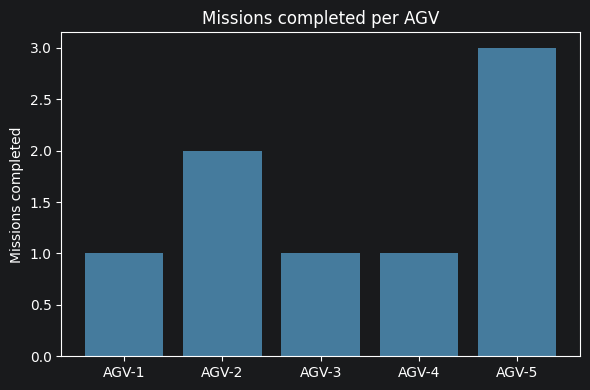

In [33]:
rows = [{
    "AGV": a.label,
    "missions_completed": a.missions_completed,
    "distance_traveled": a.distance_traveled,
    "final_battery_%": round(a.battery, 1),
    "final_status": a.status,
} for a in model.agvs]
results_df = pd.DataFrame(rows)
display(results_df)

total_completed = sum(r["missions_completed"] for r in rows)
print(f"Total missions completed: {total_completed} / {len(model.missions)}")
print(f"Missions still pending or in progress: {len(model.missions) - total_completed}")
print(f"Negotiation events -- out-of-turn seizures: {model.stats['mission_defect_seize']}, "
      f"reconsidered (mutual defection): {model.stats['mission_mutual_defect']}")
print(f"Collision events -- yields/reroutes: {model.stats['collision_yield']}, "
      f"reconsidered (mutual defection): {model.stats['collision_mutual_defect']}")
print(f"Pedestrian-crossing events -- reroutes: {model.stats['pedestrian_reroute']}, "
      f"waits: {model.stats['pedestrian_wait']}")
print(f"\nStatic obstacles ({len(model.obstacles)}, drawn once, connectivity-checked): {sorted(model.obstacles)}")
print(f"Pedestrian crossing cells: {sorted(model.PEDESTRIAN_CELLS)}, "
      f"active {model.PEDESTRIAN_ACTIVE_DURATION}/{model.PEDESTRIAN_PERIOD} steps")

fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.bar(results_df["AGV"], results_df["missions_completed"], color="#457b9d")
ax2.set_ylabel("Missions completed")
ax2.set_title("Missions completed per AGV")
plt.tight_layout()
plt.savefig("missions_per_agv.png", dpi=150)
plt.show()

# Step 13 - Animation and full log

The animation replays every recorded step: AGVs move cell by cell along their path, colored by
status, with their id and battery on top. Pallets are drawn on their rack (`visual_pallet_position`,
Step 9) or at their production/dock cell, and hidden while `being_transported` (i.e. inside an AGV).
Obstacles show up as hatched grey cells, and the pedestrian crossing switches between yellow (clear)
and red (active) so the schedule is visible frame by frame. After that I print the full log, as
proof the negotiation/collision stuff actually happened and isn't just sitting unused in the code.

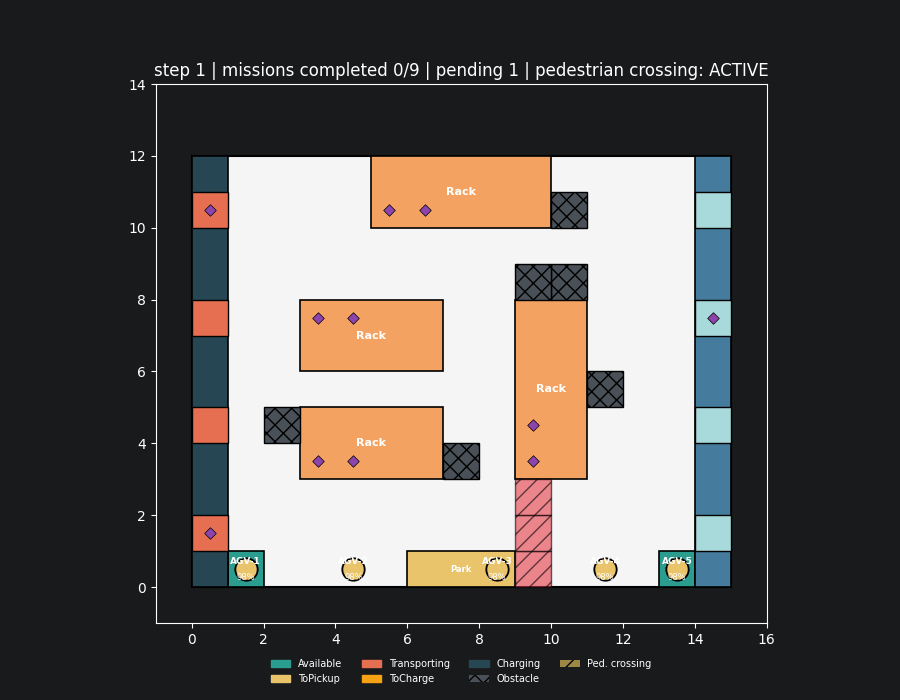

In [34]:
def draw_environment_base(ax, config):
    W, H = config["grid_width"], config["grid_height"]
    ax.add_patch(mpatches.Rectangle((0, 0), W, H, facecolor=COLORS["corridor"], edgecolor="black", linewidth=1.5))
    for gx in range(W + 1):
        ax.plot([gx, gx], [0, H], color="#dddddd", linewidth=0.5, zorder=0)
    for gy in range(H + 1):
        ax.plot([0, W], [gy, gy], color="#dddddd", linewidth=0.5, zorder=0)
    for r in config["racks"]:
        draw_block(ax, r["x"], r["y"], r["w"], r["h"], COLORS["rack"], "Rack", fontsize=8)
    for cs in config["charging_stations"]:
        draw_block(ax, cs["x"], cs["y"], cs["w"], cs["h"], COLORS["charging_station"], "CS", fontsize=7)
    p = config["parking_slot"]
    draw_block(ax, p["x"], p["y"], p["w"], p["h"], COLORS["parking_slot"], "Park", fontsize=6)
    pl = config["production_line"]
    draw_block(ax, pl["x"], pl["y"], pl["w"], pl["h"], COLORS["production_line"], "", fontsize=8)
    for oy in pl["output_rows"]:
        ax.add_patch(mpatches.Rectangle((pl["x"], oy), pl["w"], 1, facecolor="#e76f51", edgecolor="black", zorder=3))
    td = config["truck_dock"]
    draw_block(ax, td["x"], td["y"], td["w"], td["h"], COLORS["truck_dock"], "", fontsize=8)
    for dy in td["door_rows"]:
        ax.add_patch(mpatches.Rectangle((td["x"], dy), td["w"], 1, facecolor="#a8dadc", edgecolor="black", zorder=3))


STATUS_COLORS = {
    "Available": "#2a9d8f", "ToPickup": "#e9c46a", "Transporting": "#e76f51",
    "ToCharge": "#f4a213", "Charging": "#264653",
}

fig3, ax3 = plt.subplots(figsize=(9, 7))
n_missions = len(model.missions)


def render_frame(i):
    ax3.clear()
    frame = model.history[i]
    draw_environment_base(ax3, CONFIG)
    for (ox, oy) in model.obstacles:
        ax3.add_patch(mpatches.Rectangle((ox, oy), 1, 1, facecolor="#495057", edgecolor="black",
                                          hatch="xx", zorder=2))
    ped_active = frame["pedestrian_active"]
    ped_color = "#e63946" if ped_active else "#f4d35e"
    for (px, py) in model.PEDESTRIAN_CELLS:
        ax3.add_patch(mpatches.Rectangle((px, py), 1, 1, facecolor=ped_color, alpha=0.6,
                                          edgecolor="black", hatch="//", zorder=2))
    for pid, pos, status in frame["pallets"]:
        if status != "being_transported":
            vx, vy = model.visual_pallet_position(pos)
            ax3.scatter(vx + 0.5, vy + 0.5, marker="D", s=35,
                        color=COLORS["pallet_position"], edgecolor="black", linewidth=0.5, zorder=5)
    for label, pos, battery, status, carried in frame["agvs"]:
        color = STATUS_COLORS.get(status, "gray")
        ax3.scatter(pos[0] + 0.5, pos[1] + 0.5, s=260, color=color, edgecolor="black", linewidth=1.3, zorder=6)
        ax3.text(pos[0] + 0.5, pos[1] + 0.72, label, ha="center", va="center",
                 fontsize=6.5, weight="bold", zorder=7)
        ax3.text(pos[0] + 0.5, pos[1] + 0.28, f"{battery:.0f}%", ha="center", va="center",
                 fontsize=6, color="white", zorder=7)
    ax3.set_xlim(-1, CONFIG["grid_width"] + 1)
    ax3.set_ylim(-1, CONFIG["grid_height"] + 2)
    ax3.set_aspect("equal")
    step_t, comp, pend = frame["t"], frame["completed"], frame["pending"]
    ped_label = "ACTIVE" if ped_active else "clear"
    ax3.set_title(f"step {step_t} | missions completed {comp}/{n_missions} | pending {pend} | "
                  f"pedestrian crossing: {ped_label}")
    legend_items = [mpatches.Patch(color=c, label=s) for s, c in STATUS_COLORS.items()]
    legend_items.append(mpatches.Patch(facecolor="#495057", hatch="xx", label="Obstacle"))
    legend_items.append(mpatches.Patch(facecolor="#f4d35e", alpha=0.6, hatch="//", label="Ped. crossing"))
    ax3.legend(handles=legend_items, loc="upper center", bbox_to_anchor=(0.5, -0.05),
               ncol=4, fontsize=7, frameon=False)


anim = animation.FuncAnimation(fig3, render_frame, frames=len(model.history), interval=200)
anim.save("agv_simulation.gif", writer=animation.PillowWriter(fps=5))
plt.close(fig3)
display(Image(filename="agv_simulation.gif"))

In [35]:
print(f"Full log ({len(model.log)} lines):\n")
for line in model.log:
    print(line)

Full log (286 lines):

[t=00] Mission M01 published
[t=00] Mission M02 published
[t=00] Mission M03 published
[t=00] Mission M04 published
[t=00] Mission M05 published
[t=00] Mission M06 published
[t=01]   AGV-1 bid: 22.0 (dist=14, battery=100.0%)
[t=01]   AGV-2 bid: 20.0 (dist=15, battery=100.0%)
[t=01]   AGV-3 bid: 24.0 (dist=13, battery=100.0%)
[t=01]   AGV-4 bid: 14.0 (dist=18, battery=100.0%)
[t=01]   AGV-5 bid: 18.0 (dist=16, battery=100.0%)
[t=01]   M01: all agents cooperate (C strongly dominates D) -> negotiation winner is AGV-3
[t=01] AGV-3 accepts Mission M01
[t=01]   AGV-3 unavailable (status=ToPickup)
[t=01]   M02: AGV-1 DEFECTS and seizes the mission out of turn (payoff if it had cooperated instead: 10)
[t=01] AGV-1 accepts Mission M02
[t=01]   AGV-1 unavailable (status=ToPickup)
[t=01]   AGV-3 unavailable (status=ToPickup)
[t=01]   AGV-2 bid: 38.0 (dist=6, battery=100.0%)
[t=01]   AGV-4 bid: -12.0 (dist=31, battery=100.0%)
[t=01]   AGV-5 bid: -8.0 (dist=29, battery=100.0%

# Brief Analysis (M3)

**1. How did you represent each AGV as an autonomous agent?**
Each AGV is a real `ap.Agent` (`AGVAgent`), I create 5 of them as an `ap.AgentList` inside
`MultiAGVSystem`. Every one keeps its own position, battery, status, mission, etc. and a `label`
(`AGV-1` to `AGV-5`) so I can tell them apart in the log and the animation -- they're 5 separate
agents, not one point copied 5 times.

**2. What information is included in the internal state of each AGV?**
`s_i = (position_i, battery_i, status_i, mission_i)` like asked, plus a couple of extra fields I
needed: `carried_pallet`, `path` (what's left of its BFS route), and `missions_completed` /
`distance_traveled`, which I reuse both in the negotiation/priority formulas and in the results
table at the end. `status_i` actually has 5 values instead of 4: I added `ToCharge` to separate
"on its way to the charger" from "actually plugged in and charging" (`Charging`).

**3. How are missions represented?**
`M_k = (O_k, D_k, P_k, S_k)`, status goes `Pending -> Assigned -> InProgress -> Completed`. Missions
are just plain objects, not agents, they don't decide anything by themselves. I kept racks and
pallets separate on purpose (`Rack != Pallet`): the racks are the static shelves from M2, the pallets
are the `Pallet` objects that actually get created/reserved/moved, and I draw them sitting on the
rack even though the real walkable pickup point is the aisle cell right in front of it.

**4. How is information about a new mission communicated to the AGVs?**
Same sequence as in the brief: mission published -> AGVs receive it -> they evaluate it -> they
respond. When a mission goes `Pending`, `_negotiate()` sends `Message_k = (MissionID, Origin,
Destination, Pallet)` to every eligible AGV (I print a concrete example in Step 10), and each one
either bids or Defects, both get logged.

**5. What information does an AGV use to decide whether a mission is convenient?**
Its distance to the mission's origin (BFS on the real grid, not straight-line), its battery, and how
many missions it's already done, combined into `U_{i,k} = -w_d D_{i,k} + w_b B_i - w_l L_i` with the
weights given in the brief.

**6. How do AGVs negotiate when multiple agents are interested in the same mission?**
Two layers. First a normal auction: every eligible AGV bids `U_{i,k}`, highest one wins. Second, on
top of that, the Cooperate/Defect game from Step 7: since Cooperate strongly dominates Defect, a
rational AGV should always cooperate, so most of the time it really does just come down to the
auction -- but I let AGVs Defect sometimes anyway (more likely when they're getting low on battery),
so I can actually show what happens when one does: it grabs the mission out of turn, or if two do it
at once, they cancel each other out and the mission gets retried next step. Both show up in the log
(look for "DEFECTS and seizes" and "mutual defection ... reconsidering").

**7. How does your implementation prevent multiple AGVs from executing the same mission?**
As soon as a mission gets accepted, its status flips from `Pending` to `Assigned` and its pallet to
`reserved`, so no other AGV can bid on it or seize it afterwards. AGVs also only bid while they're
`Available`, so one already on a mission can't accidentally take a second one. On the movement side,
`_resolve_and_move()` makes sure two AGVs never end a step on the same cell (see question 10), and I
checked this over the whole run -- it never happens.

**8. Where can collaboration between agents be observed?**
Mostly in the negotiation log -- an AGV that's busy or low on battery logs itself as unavailable
instead of bidding, so the next best available AGV picks up the mission -- and now also in the
collision log: a lower-priority AGV yields to a higher one, an idle AGV steps aside so it's not in
the way, an AGV reroutes around a parked one instead of pushing through. All of these are basically
one AGV's situation changing what another one has to do next.

**9. How does battery level affect AGV behavior?**
Battery goes down by `c_d = 1.5` per cell moved. Below 30% the AGV stops bidding on new missions and
heads to charge once it's free; it charges at `r_c = 10` per step until it's back above 80%, then
it's available again. Battery also affects both game-theory parts: it raises how likely an AGV is to
Defect when it's getting low, and it's one of the three inputs to the movement priority score.

**10. Did you handle collisions (and other physical hazards)? How?**
Yes, at three different levels actually. AGV vs AGV is the main one: `_resolve_and_move()` plans
everyone's next cell before anyone moves and sorts out same-cell conflicts, swaps, and an AGV blocked
by a parked one, using priority plus the occasional Defect roll so it's not 100% deterministic. AGV
vs obstacle: I added 6 random obstacle cells that get placed once at the start (checked so they never
cut the grid in half) and merged into the walkable mask, so BFS just never routes through them, same
as a rack. AGV vs pedestrian: I added a fixed crossing that's active on a schedule, and I decided
this one shouldn't go through the Cooperate/Defect game at all, since a pedestrian isn't negotiating
for anything, it's just a hard rule -- an AGV is never allowed to step there while it's active, full
stop, it reroutes if it can or waits if it can't. I checked the whole run afterwards and there's
never a step with two AGVs on the same cell, an AGV on an obstacle, or an AGV on an active crossing
cell.

**11. What are the main limitations of your current strategy?**
The Cooperate/Defect probabilities are hand-picked, not learned or provably optimal, and I made
defection somewhat arbitrary on purpose so the mechanism actually shows up in the log. Paths are
recomputed reactively, only when something's actually in the way (or the crossing just turned on),
not planned ahead for the whole fleet, so there can still be some short congestion in tighter spots.
The obstacles don't move or change during a run, and the pedestrian schedule is a fixed pattern, not
really random. Charging stations don't have a capacity limit, and missions get published on a fixed
schedule instead of coming from something more realistic like actual demand.

**12. Which component of your current model would you improve using an intelligent technique in the
next stage?**
Probably mission assignment and collision priority: right now they're both fixed formulas with
hand-picked weights, a learned policy (Q-Learning or an MDP over AGV/mission/traffic state) could
balance battery, distance and congestion a lot better than that, especially once there are more AGVs
and missions competing for the same aisles.